In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import OptimalBattery.scripts._3experimental_design._1hcp_task_covariance as sh
import os
import seaborn as sb
from OptimalBattery.global_config import data_dir, save_dir
from matplotlib import gridspec
import OptimalBattery.design as ds



In [17]:
base_dir = f"{data_dir}/FunctionalFusion_new"

## Plot covariance matrics of the HCP task sessions and ratio of baseline noise to total noise

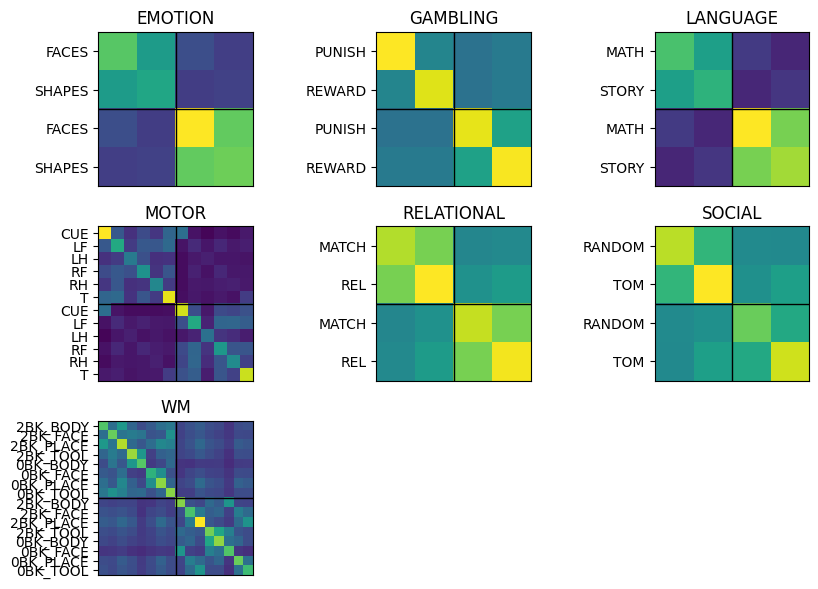

In [18]:
COV, tasks, infos = sh.get_covariance_matrices(space = 'fs32k',base_dir=base_dir)
plt.figure(figsize=(9,6))
sh.plot_all_covariances(COV,tasks,infos)
plt.savefig(f"{save_dir}/BlockedvsInterspersed/hcp_task_covariances.pdf",bbox_inches='tight')

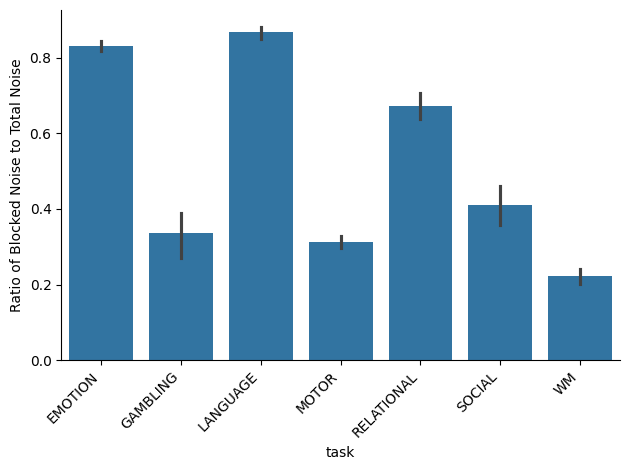

In [19]:
D = sh.estimate_all_components(COV,tasks,infos)
D['n_ratio'] = D['noise_block'] / (D['noise']+D['noise_block'])
sb.barplot(data=D, x='task', y='n_ratio')
plt.ylabel('Ratio of Blocked Noise to Total Noise')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sb.despine()
plt.savefig(f"{save_dir}/BlockedvsInterspersed/hcp_task_noise_ratios.pdf",bbox_inches='tight')



In [20]:
pd.pivot_table(D, index='task', values=['n_ratio'], aggfunc=[np.mean,np.std])

,mean,std
,n_ratio,n_ratio
task,,
EMOTION,0.830814,0.048414
GAMBLING,0.335336,0.211636
LANGUAGE,0.867149,0.060911
MOTOR,0.311990,0.058245
RELATIONAL,0.673159,0.125053
SOCIAL,0.411350,0.183399
WM,0.221486,0.075919


# Blocked vs interspersed

Without removing instruction time points from interspersed

In [21]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'design_simulation.tsv')
D = pd.read_csv(saved_file, sep='\t')

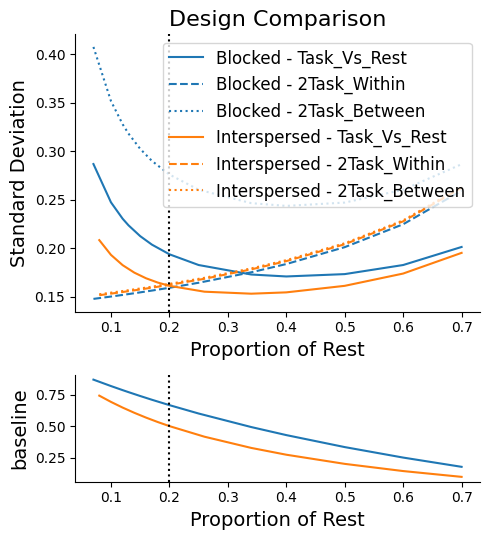

In [22]:
plt.figure(figsize=(5,5.5))
gs = gridspec.GridSpec(3, 1)
ax0 = plt.subplot(gs[0:2,0])
ds.plot_contrast_variance(D)
ax1 = plt.subplot(gs[2,0])
ds.plot_baseline_noise(D)
plt.savefig(f"{save_dir}/BlockedvsInterspersed/design_simulation.pdf",bbox_inches='tight')


 remove 5 instruction time points from interspersed

In [23]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'design_simulation_instruction.tsv')
D = pd.read_csv(saved_file, sep='\t')

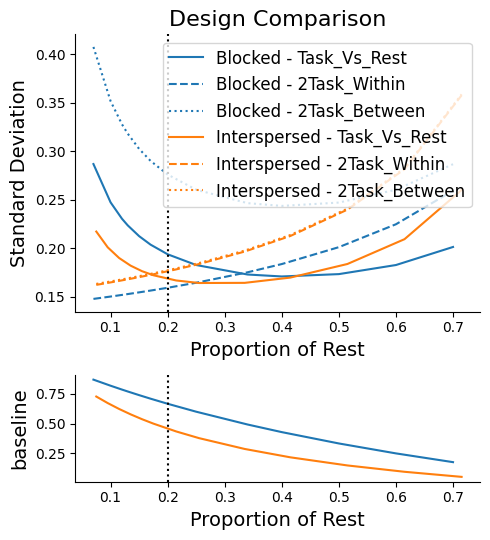

In [24]:
plt.figure(figsize=(5,5.5))
gs = gridspec.GridSpec(3, 1)
ax0 = plt.subplot(gs[0:2,0])
ds.plot_contrast_variance(D)
ax1 = plt.subplot(gs[2,0])
ds.plot_baseline_noise(D)
plt.savefig(f"{save_dir}/supp/design_simulation_instruction.pdf",bbox_inches='tight')
